# One-Step Virtual Update Interference Probe (HiP-AD)

**Goal:** Measure task-to-task interference via a *one-step virtual update probe* at the **mini-batch** level (not single-sample).

For a fixed mini-batch $B$ and parameters $\theta$:

1. Compute baseline $L_{\text{plan}}(B, \theta)$.
2. For each probe task $i \in \{\text{det}, \text{map}, \text{motion}, \text{ego}, \text{plan}\}$:
   - Compute $g_i = \partial L_i(B, \theta) / \partial W_{\text{shared}}$
   - Virtual step: $\theta_i' = \theta - \alpha \cdot g_i$ (or normalized: $\theta - \alpha \cdot g_i / \|g_i\|$)
   - Recompute **on the same batch**: $L_{\text{plan}}(B, \theta_i')$
   - $\Delta L_{\text{plan} \leftarrow i} = L_{\text{plan}}(B, \theta_i') - L_{\text{plan}}(B, \theta)$
   - Immediately restore $\theta$.
3. Aggregate over N mini-batches: mean / std / harmful ratio.

**Interpretation:**

| $\Delta L_{\text{plan} \leftarrow i}$ | Meaning |
|---|---|
| $> 0$ | Task $i$'s local step is **harmful** to planning |
| $< 0$ | Task $i$'s local step is **helpful** to planning |
| $\approx 0$ | Weak local influence |

**Design principles:**
- Mini-batch gradients (matches real optimizer step).
- Plain SGD-style virtual step (no AdamW state mixing).
- Parameter restore after every probe — optimizer.step() never called.
- Same batch reused for before/after forward.
- Shared params match `analyze_gradient_conflict.py` (backbone / neck / norm / ffn / fc_before / fc_after). Note: backbone/neck default extraction is limited to decoder-side shared layers; override `SHARED_LAYERS` below if you want to include backbone/neck explicitly.


## 1. Configuration

Edit these values to match your run. All knobs are centralized here so the rest of the notebook is reusable.

In [1]:
# ---------------------------------------------------------------------------
# User-tunable configuration (equivalent to CLI args in a standalone script)
# ---------------------------------------------------------------------------
CONFIG_PATH     = '/home/yongjae/e2e/HiP-AD/projects/configs/experiments/E2_E1_stage2_18ep.py'
CHECKPOINT_PATH = '/home/yongjae/e2e/HiP-AD/data/ckpts/E2_E1_stage2_18ep/iter_2344.pth'

# --- Match training-iteration data volume -----------------------------------
# E2_E1_stage2_18ep.py: num_gpus=2, batch_size=6 per GPU.
# Effective mini-batch per optimizer step = num_gpus * batch_size = 12.
# Probing runs on a single GPU, so BATCH_SIZE = 12 makes every probed
# mini-batch process the same data volume as one real training iteration.
TRAIN_NUM_GPUS    = 2
TRAIN_PER_GPU_BS  = 6
EFFECTIVE_BATCH   = TRAIN_NUM_GPUS * TRAIN_PER_GPU_BS  # = 12

NUM_BATCHES     = 20                  # How many mini-batches to probe
BATCH_SIZE      = EFFECTIVE_BATCH     # single-GPU batch == 1 training iteration worth of data
DEVICE          = 'cuda:0'
FP16            = True
SEED            = 42

SHARED_LAYERS   = ['backbone', 'neck', 'norm', 'ffn', 'fc_before', 'fc_after']
LAST_N_LAYERS   = None        # None -> all decoder layers
PARAM_SCOPE     = 'shared_only'   # 'shared_only' | 'all'
NO_SELECTIVE_EVAL = False     # True -> skip _selective_eval (use raw train mode)

FOCUS_TASK      = 'plan'
PROBE_TASKS     = ['det', 'map', 'motion', 'ego', 'plan']
VIRTUAL_LR      = 1e-3        # alpha for one-step probe
NORMALIZE_STEP  = False       # True -> normalize g / ||g|| before step
NORMALIZE_SCOPE = 'all'       # 'all' -> full shared-grad vector norm; 'group' -> per group norm

OUTPUT_DIR      = 'gradient_analysis_results/one_step_probe'
SAVE_PER_BATCH  = True
SAVE_JSON       = True
SAVE_CSV        = True


FREEZE_MATCHING  = True      # Freeze Hungarian matching between baseline & after-step forwards (Phase 1: det + map)

# ---------------------------------------------------------------------------
print(f"Config: {CONFIG_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Training setup: num_gpus={TRAIN_NUM_GPUS}, per-GPU batch={TRAIN_PER_GPU_BS} "
      f"-> effective batch = {EFFECTIVE_BATCH}")
print(f"Probe BATCH_SIZE (single-GPU) = {BATCH_SIZE} (matches training effective batch)")
print(f"Probe tasks: {PROBE_TASKS} | focus: {FOCUS_TASK}")
print(f"Virtual LR: {VIRTUAL_LR} | normalize: {NORMALIZE_STEP} ({NORMALIZE_SCOPE})")
print(f"Num batches: {NUM_BATCHES} | param_scope: {PARAM_SCOPE}")

print(f"FREEZE_MATCHING = {FREEZE_MATCHING}")


Config: /home/yongjae/e2e/HiP-AD/projects/configs/experiments/E2_E1_stage2_18ep.py
Checkpoint: /home/yongjae/e2e/HiP-AD/data/ckpts/E2_E1_stage2_18ep/iter_2344.pth
Training setup: num_gpus=2, per-GPU batch=6 -> effective batch = 12
Probe BATCH_SIZE (single-GPU) = 12 (matches training effective batch)
Probe tasks: ['det', 'map', 'motion', 'ego', 'plan'] | focus: plan
Virtual LR: 0.001 | normalize: False (all)
Num batches: 20 | param_scope: shared_only
FREEZE_MATCHING = True


## 2. Imports & helper reuse

We re-use the core helpers from `analyze_gradient_conflict.py` directly rather than duplicating them.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

import sys
import json
import math
import csv
import contextlib
import traceback
from functools import partial
from collections import OrderedDict, defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Resolve project root (HiP-AD repo root = parent of tools/)
_NB_DIR = os.path.abspath(os.path.dirname('.'))
# When run from repo root: '.'; when run from tools/: parent
_CANDIDATES = [os.path.abspath('.'), os.path.abspath('..')]
PROJECT_ROOT = None
for c in _CANDIDATES:
    if os.path.isdir(os.path.join(c, 'projects')) and os.path.isdir(os.path.join(c, 'tools')):
        PROJECT_ROOT = c
        break
assert PROJECT_ROOT is not None, \
    "Could not locate HiP-AD project root. Run notebook from repo root or tools/."
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
TOOLS_DIR = os.path.join(PROJECT_ROOT, 'tools')
if TOOLS_DIR not in sys.path:
    sys.path.insert(0, TOOLS_DIR)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

# MMCV / MMDet
from mmcv import Config
from mmcv.runner import load_checkpoint, wrap_fp16_model
from mmcv.parallel import collate, MMDataParallel
from mmdet.models import build_detector

# HiP-AD plugin imports (registers custom modules)
import projects.mmdet3d_plugin  # noqa: F401
from projects.mmdet3d_plugin.datasets.builder import custom_build_dataset

# Reuse helpers from analyze_gradient_conflict.py (no duplication)
from analyze_gradient_conflict import (
    TASK_GROUPS,
    _sum_task_loss,
    _selective_eval,
    move_to_device,
    get_shared_parameters_grouped,
    compute_task_gradient_grouped,
    compute_cosine_similarity,
)

print("Reused helpers:",
      "TASK_GROUPS, _sum_task_loss, _selective_eval, move_to_device, "
      "get_shared_parameters_grouped, compute_task_gradient_grouped, compute_cosine_similarity")

/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /home/yongjae/e2e/HiP-AD


/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Use flash_attn_varlen_kvpacked_func
Reused helpers: TASK_GROUPS, _sum_task_loss, _selective_eval, move_to_device, get_shared_parameters_grouped, compute_task_gradient_grouped, compute_cosine_similarity


In [3]:
import sys, matplotlib
print(sys.executable)
print(matplotlib.__version__, matplotlib.__file__)

/home/yongjae/miniconda3/envs/hipad/bin/python
3.5.3 /home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/matplotlib/__init__.py


## 3. Core probe functions

New, probe-specific logic. These are the functions *added* on top of what `analyze_gradient_conflict.py` already provides.

- `extract_probe_params`: picks the parameter set to virtually update (shared_only or all).
- `backup_params` / `restore_params`: checkpoint & rollback of parameter tensors (no optimizer state).
- `apply_virtual_step`: applies `p ← p − α · g` in-place (raw or normalized).
- `forward_and_get_losses`: single forward pass on a cached batch; returns loss dict and planning-loss tensor **with grad graph retained** when needed for gradient computation.
- `compute_planning_loss_value`: pure `no_grad` forward for the *recompute* pass after a virtual step.
- `run_probe_on_batch`: full before / per-task-probe / after pipeline for one mini-batch.
- `run_full_probe`: outer loop over `NUM_BATCHES` mini-batches.

In [4]:
EPS = 1e-12


def extract_probe_params(
    model: nn.Module,
    shared_layers: List[str],
    last_n_layers: Optional[int],
    param_scope: str,
) -> Tuple[OrderedDict, OrderedDict]:
    """Return (param_groups, group_meta). Matches the shape used by
    compute_task_gradient_grouped so we can reuse it directly.

    param_scope:
      - 'shared_only' : delegate to get_shared_parameters_grouped
      - 'all'         : every requires_grad param, in a single '_all' group
    """
    if param_scope == 'shared_only':
        param_groups, group_meta = get_shared_parameters_grouped(
            model, shared_layers, last_n_layers
        )
        return param_groups, group_meta

    if param_scope == 'all':
        params = OrderedDict()
        for name, p in model.named_parameters():
            if p.requires_grad:
                params[name] = p
        param_groups = OrderedDict([('_all_params', params)])
        group_meta = OrderedDict([('_all_params', {
            'decoder_idx': -1, 'op_type': 'all', 'global_layer_idx': -1,
        })])
        return param_groups, group_meta

    raise ValueError(f"Unknown param_scope: {param_scope}")


def flatten_param_group(param_groups: OrderedDict) -> List[nn.Parameter]:
    """Ordered flat list of parameters across all groups (matches
    compute_task_gradient_grouped's internal ordering)."""
    out: List[nn.Parameter] = []
    for _, params in param_groups.items():
        out.extend(params.values())
    return out


def backup_params(params: List[nn.Parameter]) -> List[torch.Tensor]:
    """CPU-side clone of each parameter tensor. CPU to avoid doubling GPU memory."""
    return [p.detach().clone() for p in params]


def restore_params(params: List[nn.Parameter], backup: List[torch.Tensor]) -> None:
    """In-place restore — no optimizer state involved."""
    with torch.no_grad():
        for p, b in zip(params, backup):
            p.data.copy_(b.data)


def apply_virtual_step(
    params: List[nn.Parameter],
    grad_flat: torch.Tensor,
    lr: float,
    normalize: bool,
    normalize_scope: str,
    group_boundaries: Optional[List[Tuple[int, int]]] = None,
) -> float:
    """In-place: p <- p - lr * g (or normalized variant). Returns the gradient
    norm actually used (for logging).

    normalize_scope:
      'all'   -> single shared-grad vector norm
      'group' -> per-group norm (needs group_boundaries: list of (start, end))
    """
    used_norm = float(torch.norm(grad_flat).item())

    if normalize and normalize_scope == 'all':
        g_norm = torch.norm(grad_flat) + EPS
        step_vec = grad_flat / g_norm
    elif normalize and normalize_scope == 'group':
        assert group_boundaries is not None, "group normalize requires boundaries"
        step_vec = grad_flat.clone()
        for (s, e) in group_boundaries:
            sub_norm = torch.norm(step_vec[s:e]) + EPS
            step_vec[s:e] = step_vec[s:e] / sub_norm
    else:
        step_vec = grad_flat

    with torch.no_grad():
        cursor = 0
        for p in params:
            n = p.numel()
            g_slice = step_vec[cursor:cursor + n].view_as(p)
            p.data.add_(g_slice.to(p.device, dtype=p.dtype), alpha=-lr)
            cursor += n
    return used_norm


def group_boundaries_from(param_groups: OrderedDict) -> List[Tuple[int, int]]:
    bounds = []
    cursor = 0
    for _, params in param_groups.items():
        n = sum(p.numel() for p in params.values())
        bounds.append((cursor, cursor + n))
        cursor += n
    return bounds


In [5]:
def _sum_task_loss_nograd(loss_dict: Dict[str, torch.Tensor], task_name: str) -> Optional[torch.Tensor]:
    """Variant of _sum_task_loss that does NOT require requires_grad.

    Used for the 'after virtual step' recompute, which we run under torch.no_grad()
    so the task losses will not have grad. The original _sum_task_loss filters
    those out.
    """
    from analyze_gradient_conflict import match_loss_key
    prefixes = TASK_GROUPS.get(task_name, [])
    task_loss = None
    for key, val in loss_dict.items():
        if match_loss_key(key, prefixes) and isinstance(val, torch.Tensor):
            task_loss = val if task_loss is None else task_loss + val
    return task_loss


def clone_batch(data: Dict) -> Dict:
    """Deep-ish copy of a batch dict. mmcv DataContainer objects are kept as-is
    (they are already immutable for our purposes); tensors are cloned."""
    out = {}
    for k, v in data.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.clone()
        elif isinstance(v, list):
            out[k] = [x.clone() if isinstance(x, torch.Tensor) else x for x in v]
        elif isinstance(v, dict):
            out[k] = clone_batch(v)
        else:
            out[k] = v
    return out


def forward_losses(model: nn.Module, data: Dict, device: str, fp16: bool,
                   selective_eval: bool) -> Dict[str, torch.Tensor]:
    """Single forward pass with the training loss heads. Keeps the grad graph.

    Caller owns the returned dict; must zero_grad afterwards.
    """
    data_on_dev = move_to_device(data, device)
    model.train()
    ctx = _selective_eval(model) if selective_eval else contextlib.nullcontext()
    with ctx:
        with torch.cuda.amp.autocast(enabled=fp16):
            img = data_on_dev.pop('img')
            outputs = model(img=img, **data_on_dev)
    if not isinstance(outputs, dict):
        raise RuntimeError("Model output is not a loss dict — check training mode.")
    return outputs


@torch.no_grad()
def forward_losses_nograd(model: nn.Module, data: Dict, device: str, fp16: bool,
                          selective_eval: bool) -> Dict[str, torch.Tensor]:
    """No-grad forward used for the recompute pass. Cheaper and leak-free."""
    data_on_dev = move_to_device(data, device)
    model.train()
    ctx = _selective_eval(model) if selective_eval else contextlib.nullcontext()
    with ctx:
        with torch.cuda.amp.autocast(enabled=fp16):
            img = data_on_dev.pop('img')
            outputs = model(img=img, **data_on_dev)
    return outputs


def extract_task_loss_values(loss_dict: Dict[str, torch.Tensor],
                             tasks: List[str]) -> Dict[str, float]:
    """Scalarize each task's summed loss. Works with or without grad."""
    out = {}
    for t in tasks:
        lt = _sum_task_loss_nograd(loss_dict, t)
        out[t] = float(lt.item()) if lt is not None else float('nan')
    return out


In [6]:
TARGET_TASKS_DEFAULT = list(TASK_GROUPS.keys())


def extract_all_task_losses_nograd(loss_dict, tasks):
    out = {}
    for t in tasks:
        lt = _sum_task_loss_nograd(loss_dict, t)
        out[t] = float(lt.item()) if lt is not None else float('nan')
    return out


def run_probe_on_batch(
    model: nn.Module,
    data: Dict,
    param_groups: OrderedDict,
    probe_tasks: List[str],
    focus_task: str,
    device: str,
    fp16: bool,
    virtual_lr: float,
    normalize_step: bool,
    normalize_scope: str,
    selective_eval: bool,
    batch_idx: int,
    target_tasks: Optional[List[str]] = None,
    freeze_matching: bool = True,
) -> Dict:
    """N x N probe. When freeze_matching=True, Hungarian results from the
    baseline forward are cached and replayed in every after-step forward so
    the loss is evaluated as a smooth function of shared params only.
    """
    if target_tasks is None:
        target_tasks = list(TASK_GROUPS.keys())

    params_flat = flatten_param_group(param_groups)
    g_bounds = group_boundaries_from(param_groups)
    data_cache = clone_batch(data)

    # ----- Baseline forward (RECORD Hungarian assignments) -------------
    # Deterministic reset: instance banks + dn_metas + RNG snapshot for replay.
    _probe_rng_state = reset_for_deterministic_forward(model, rng_state=None)
    if freeze_matching:
        matching_cache.start_record()
    try:
        loss_dict = forward_losses(model, clone_batch(data_cache), device, fp16, selective_eval)
    finally:
        if freeze_matching:
            matching_cache.stop()
    n_records = len(matching_cache.records) if freeze_matching else 0

    baseline_task_losses = extract_all_task_losses_nograd(loss_dict, list(TASK_GROUPS.keys()))

    # ----- Per-task gradients on shared params -------------------------
    task_grads: Dict[str, Optional[torch.Tensor]] = {}
    tasks_to_compute = list(probe_tasks)
    if focus_task not in tasks_to_compute:
        tasks_to_compute.append(focus_task)
    for i, task in enumerate(tasks_to_compute):
        retain = (i < len(tasks_to_compute) - 1)
        grad_dict = compute_task_gradient_grouped(
            model, loss_dict, task, param_groups, retain_graph=retain,
        )
        task_grads[task] = grad_dict['_all'].detach().cpu() if grad_dict is not None else None

    del loss_dict
    model.zero_grad(set_to_none=True)
    torch.cuda.empty_cache()

    # ----- Per-source virtual step + target measurement ----------------
    backup = backup_params(params_flat)
    per_probe: Dict[str, Dict] = {}
    fallback_total = 0

    for src in probe_tasks:
        g_src = task_grads.get(src)
        record = {
            'grad_norm': float('nan'),
            'failed': False,
            'error': None,
            'cos_vs': {},
            'per_target': {},
            'replay_fallback_count': 0,
        }
        for tgt in target_tasks:
            g_tgt = task_grads.get(tgt)
            if g_src is not None and g_tgt is not None:
                record['cos_vs'][tgt] = compute_cosine_similarity(g_src, g_tgt)
            else:
                record['cos_vs'][tgt] = float('nan')

        if g_src is None or torch.norm(g_src).item() < EPS:
            record['failed'] = True
            record['error'] = 'zero_or_missing_gradient'
            for tgt in target_tasks:
                record['per_target'][tgt] = {'loss_after': float('nan'),
                                             'delta': float('nan'),
                                             'rel_delta': float('nan')}
            per_probe[src] = record
            continue

        try:
            g_device = g_src.to(params_flat[0].device)
            used_norm = apply_virtual_step(
                params_flat, g_device, virtual_lr,
                normalize=normalize_step, normalize_scope=normalize_scope,
                group_boundaries=g_bounds,
            )
            record['grad_norm'] = used_norm

            # ------- After-step forward (REPLAY matching) -------------
            # Restore RNG to the baseline snapshot so DN rand_like noise is identical.
            reset_for_deterministic_forward(model, rng_state=_probe_rng_state)
            if freeze_matching:
                matching_cache.start_replay()
            try:
                loss_after_dict = forward_losses_nograd(
                    model, clone_batch(data_cache), device, fp16, selective_eval,
                )
            finally:
                if freeze_matching:
                    record['replay_fallback_count'] = matching_cache.fallback_count
                    fallback_total += matching_cache.fallback_count
                    matching_cache.stop()

            losses_after = extract_all_task_losses_nograd(loss_after_dict, target_tasks)
            for tgt in target_tasks:
                la = losses_after.get(tgt, float('nan'))
                base = baseline_task_losses.get(tgt, float('nan'))
                if math.isnan(la) or math.isnan(base):
                    delta, rel = float('nan'), float('nan')
                else:
                    delta = la - base
                    rel = delta / (abs(base) + EPS)
                record['per_target'][tgt] = {
                    'loss_after': la,
                    'delta': delta,
                    'rel_delta': rel,
                }
            del loss_after_dict, losses_after
        except Exception as e:
            record['failed'] = True
            record['error'] = f"{type(e).__name__}: {e}"
            traceback.print_exc()
            for tgt in target_tasks:
                record['per_target'].setdefault(tgt, {
                    'loss_after': float('nan'),
                    'delta': float('nan'),
                    'rel_delta': float('nan'),
                })
        finally:
            restore_params(params_flat, backup)
            model.zero_grad(set_to_none=True)
            torch.cuda.empty_cache()

        per_probe[src] = record

    del task_grads, backup

    return {
        'batch_idx': batch_idx,
        'baseline_task_losses': baseline_task_losses,
        'baseline_focus_loss': baseline_task_losses.get(focus_task, float('nan')),
        'focus_task': focus_task,
        'target_tasks': list(target_tasks),
        'per_probe': per_probe,
        'matching_freeze': {
            'enabled': bool(freeze_matching),
            'n_records': n_records,
            'replay_fallback_total': fallback_total,
        },
    }


## 3.5 Hungarian matching freeze (record / replay)

확률적/비연속적 요소를 제거하기 위해 scipy `linear_sum_assignment`를 record/replay 모드로 래핑합니다.

- **Baseline forward** 중에는 `record` 모드: 호출될 때마다 (row_ind, col_ind) 결과를 순서대로 캐시.
- **After-step forward** 중에는 `replay` 모드: 같은 순서로 캐시된 결과를 그대로 반환. 즉 **assignment가 고정된 "smooth" loss 함수**로 평가.

이걸 통해 det/map에서 parameter가 조금 바뀌어도 Hungarian 재할당이 일어나지 않아, 순수한 "shared-param → loss" 의존성만 남습니다.

**Patch 대상:**
- `projects.mmdet3d_plugin.models.det.target` (det main + DN matching)
- `projects.mmdet3d_plugin.models.map.target` (map matching)

Motion/plan의 argmax / top-k 기반 불연속성은 Phase 1 범위에 포함하지 않습니다.


In [7]:
# ----- Hungarian freeze: monkey-patch scipy.optimize.linear_sum_assignment ---
import scipy.optimize as _spo
import projects.mmdet3d_plugin.models.det.target as _det_tgt_mod
import projects.mmdet3d_plugin.models.map.target as _map_tgt_mod

# Save original once
if not hasattr(_spo, '_orig_lsa_saved'):
    _spo._orig_lsa_saved = _spo.linear_sum_assignment
_REAL_LSA = _spo._orig_lsa_saved


class MatchingCache:
    """Record Hungarian assignments during baseline forward, replay them during
    after-step forwards to keep the matching *identical* across parameter perturbations.
    """
    def __init__(self):
        self.records = []       # list of assignment results in call order
        self.idx = 0            # replay cursor
        self.mode = 'off'       # 'record' | 'replay' | 'off'
        self.fallback_count = 0 # number of times replay fell back to fresh compute

    def start_record(self):
        self.records = []; self.idx = 0; self.fallback_count = 0
        self.mode = 'record'

    def start_replay(self):
        self.idx = 0; self.fallback_count = 0
        self.mode = 'replay'

    def stop(self):
        self.mode = 'off'

    def __call__(self, cost, *args, **kwargs):
        if self.mode == 'record':
            out = _REAL_LSA(cost, *args, **kwargs)
            self.records.append(out)
            return out
        if self.mode == 'replay':
            if self.idx < len(self.records):
                out = self.records[self.idx]; self.idx += 1
                return out
            self.fallback_count += 1
            return _REAL_LSA(cost, *args, **kwargs)
        return _REAL_LSA(cost, *args, **kwargs)


matching_cache = MatchingCache()


def install_matching_patches():
    _det_tgt_mod.linear_sum_assignment = matching_cache
    _map_tgt_mod.linear_sum_assignment = matching_cache


def uninstall_matching_patches():
    _det_tgt_mod.linear_sum_assignment = _REAL_LSA
    _map_tgt_mod.linear_sum_assignment = _REAL_LSA


install_matching_patches()
print("[matching-freeze] installed patches on:")
print(f"  - {_det_tgt_mod.__name__}  (det main + DN Hungarian)")
print(f"  - {_map_tgt_mod.__name__}  (map Hungarian)")
print(f"[matching-freeze] FREEZE_MATCHING = {FREEZE_MATCHING}  (toggled per-batch inside run_probe_on_batch)")


# ----- InstanceBank reset: clear temporal memory between forwards -----------
from projects.mmdet3d_plugin.models.instance_bank import InstanceBank
try:
    from projects.mmdet3d_plugin.models.ego.instance_bank import EgoInstanceBank
except Exception:
    EgoInstanceBank = None
try:
    from projects.mmdet3d_plugin.models.plan.instance_bank import PlanningInstanceBank
except Exception:
    PlanningInstanceBank = None


def _is_bank_module(mod):
    bank_classes = tuple(c for c in (InstanceBank, EgoInstanceBank, PlanningInstanceBank) if c is not None)
    if bank_classes and isinstance(mod, bank_classes):
        return True
    cname = type(mod).__name__
    if (cname.endswith('Bank') or 'InstanceBank' in cname) and callable(getattr(mod, 'reset', None)):
        return True
    return False


def reset_all_instance_banks(model, verbose=True):
    """Call .reset() on every InstanceBank-like submodule so all forwards start
    from identical (empty) temporal memory. Returns (count, list_of_names)."""
    n = 0
    names = []
    for name, mod in model.named_modules():
        if _is_bank_module(mod):
            try:
                mod.reset()
                n += 1
                names.append(f"{name}  [{type(mod).__name__}]")
            except Exception as e:
                names.append(f"{name}  [{type(mod).__name__}] RESET_FAILED: {e}")
    if verbose:
        print(f"[instance-bank-reset] reset {n} banks:")
        for nm in names:
            print(f"  - {nm}")
    return n, names


_n_banks, _bank_names = reset_all_instance_banks(model if 'model' in dir() else None, verbose=False) \
    if 'model' in dir() else (None, None)
if _bank_names is not None:
    print(f"[instance-bank] detected {_n_banks} banks: {_bank_names}")
else:
    print("[instance-bank] helper defined. Will auto-reset before every forward in run_probe_on_batch.")


# ----- DN sampler state reset: clear cached dn_metas ------------------------
def reset_all_samplers(model, verbose=False):
    """Reset ``self.dn_metas = None`` on any submodule that has it (det/map samplers).
    Also clears any stateful mask/temp attributes commonly used by DN samplers."""
    n = 0
    names = []
    for name, mod in model.named_modules():
        changed = False
        for attr in ('dn_metas',):
            if hasattr(mod, attr) and not isinstance(getattr(mod, attr, None), torch.nn.Module):
                try:
                    setattr(mod, attr, None)
                    changed = True
                except Exception:
                    pass
        if changed:
            n += 1
            names.append(f"{name}  [{type(mod).__name__}]")
    if verbose:
        print(f"[sampler-reset] cleared dn_metas on {n} samplers:")
        for nm in names:
            print(f"  - {nm}")
    return n, names


# ----- Deterministic RNG snapshot: fix noise across forward passes ----------
def _snapshot_rng():
    state = {
        'cpu': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state['cuda'] = [torch.cuda.get_rng_state(i) for i in range(torch.cuda.device_count())]
    return state


def _restore_rng(state):
    torch.set_rng_state(state['cpu'])
    if 'cuda' in state:
        for i, s in enumerate(state['cuda']):
            torch.cuda.set_rng_state(s, i)


def reset_for_deterministic_forward(model, rng_state=None):
    """Full deterministic-forward reset: instance banks + dn_metas + RNG.
    If ``rng_state`` is supplied, restore it; otherwise snapshot the current
    RNG (so caller can re-use the same snapshot on subsequent forwards).
    Returns the snapshot for re-use.
    """
    reset_all_instance_banks(model)
    reset_all_samplers(model)
    if rng_state is None:
        rng_state = _snapshot_rng()
    else:
        _restore_rng(rng_state)
    return rng_state


# One-time diagnostic
if 'model' in dir():
    _n_s, _s_names = reset_all_samplers(model, verbose=True)


[matching-freeze] installed patches on:
  - projects.mmdet3d_plugin.models.det.target  (det main + DN Hungarian)
  - projects.mmdet3d_plugin.models.map.target  (map Hungarian)
[matching-freeze] FREEZE_MATCHING = True  (toggled per-batch inside run_probe_on_batch)
[instance-bank] helper defined. Will auto-reset before every forward in run_probe_on_batch.


## 4. Build model, dataloader, parameter groups

In [8]:
torch.manual_seed(SEED)
np.random.seed(SEED)

cfg = Config.fromfile(CONFIG_PATH)

if BATCH_SIZE is None:
    BATCH_SIZE = getattr(cfg.data, 'samples_per_gpu', 6)
    print(f"Auto batch_size = {BATCH_SIZE}")

cfg.data.samples_per_gpu = BATCH_SIZE
cfg.data.workers_per_gpu = min(4, BATCH_SIZE)

# Build model
print(f"Building model from {CONFIG_PATH}...")
model = build_detector(cfg.model, train_cfg=cfg.get('train_cfg'), test_cfg=cfg.get('test_cfg'))
model.init_weights()

if cfg.get('fp16', None) is not None:
    wrap_fp16_model(model)

print(f"Loading checkpoint: {CHECKPOINT_PATH}")
load_checkpoint(model, CHECKPOINT_PATH, map_location='cpu')

device_id = int(DEVICE.split(':')[1]) if ':' in DEVICE else 0
model = model.to(DEVICE)
model = MMDataParallel(model, device_ids=[device_id])

# Shared param groups (same as analyze_gradient_conflict)
param_groups, group_meta = extract_probe_params(
    model, SHARED_LAYERS, LAST_N_LAYERS, PARAM_SCOPE,
)
total_groups = len(param_groups)
total_params = sum(p.numel() for grp in param_groups.values() for p in grp.values())
print(f"\nParameter groups: {total_groups} | total params: {total_params:,}")
for gk, params in list(param_groups.items())[:10]:
    n = sum(p.numel() for p in params.values())
    meta = group_meta.get(gk, {})
    print(f"  {gk:35s}: {n:>10,} params  dec={meta.get('decoder_idx')} op={meta.get('op_type')}")
if total_groups > 10:
    print(f"  ... and {total_groups - 10} more groups")

assert total_params > 0, "No parameters selected — check SHARED_LAYERS / PARAM_SCOPE."

# Dataloader
dataset = custom_build_dataset(cfg.data.train)
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=min(4, BATCH_SIZE),
    collate_fn=partial(collate, samples_per_gpu=BATCH_SIZE), drop_last=True,
)
print(f"\nDataset size: {len(dataset)} | dataloader batch_size: {BATCH_SIZE}")


Building model from /home/yongjae/e2e/HiP-AD/projects/configs/experiments/E2_E1_stage2_18ep.py...


/home/yongjae/miniconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '
2026-04-20 21:47:45,169 - mmcv - INFO - initialize ResNet with init_cfg {'type': 'Pretrained', 'checkpoint': 'ckpts/resnet50-19c8e357.pth'}
2026-04-20 21:47:45,170 - mmcv - INFO - load model from: ckpts/resnet50-19c8e357.pth
2026-04-20 21:47:45,171 - mmcv - INFO - load checkpoint from local path: ckpts/resnet50-19c8e357.pth
2026-04-20 21:47:45,417 - mmcv - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias

2026-04-20 21:47:45,435 - mmcv - INFO - initialize FPN with init_cfg {'type': 'Xavier', 'layer': 'Conv2d', 'distribution': 'uniform'}
2026-04-20 21:47:45,649 - mmcv - INFO - 
img_backbone.conv1.weight - torch.Size([64, 3, 7, 7]): 
PretrainedInit: load from ckpts/r

Loading checkpoint: /home/yongjae/e2e/HiP-AD/data/ckpts/E2_E1_stage2_18ep/iter_2344.pth
load checkpoint from local path: /home/yongjae/e2e/HiP-AD/data/ckpts/E2_E1_stage2_18ep/iter_2344.pth

Parameter groups: 20 | total params: 5,788,672
  dec0_norm_0                        :        512 params  dec=0 op=norm
  dec0_ffn_0                         :    920,064 params  dec=0 op=ffn
  dec0_norm_1                        :        512 params  dec=0 op=norm
  dec1_norm_0                        :        512 params  dec=1 op=norm
  dec1_ffn_0                         :    920,064 params  dec=1 op=ffn
  dec1_norm_1                        :        512 params  dec=1 op=norm
  dec2_norm_0                        :        512 params  dec=2 op=norm
  dec2_ffn_0                         :    920,064 params  dec=2 op=ffn
  dec2_norm_1                        :        512 params  dec=2 op=norm
  dec3_norm_0                        :        512 params  dec=3 op=norm
  ... and 10 more groups
{'version': 'v1.0-tra

## 4.5 Loss-key diagnostic (ego 실패 원인)

One mini-batch를 흘려서 모델이 실제로 뱉는 loss key 리스트를 확인합니다. `ego` 항목이 전부 `n_failed=20` 이었는데, 원인은 보통 둘 중 하나:

1. 이 checkpoint의 config가 ego head를 끈 상태 → 출력 dict에 `ego*` key 자체가 없음.
2. ego loss key 접두사가 `TASK_GROUPS['ego']` 의 `loss_ego_*` 가 아니라 다른 이름(`ego_loss_*` 등).

아래 셀을 한 번만 돌려보면 구분됩니다.


In [9]:
# One-shot ego diagnostic. Requires cells up to §4 to have run (model + dataloader alive).
from analyze_gradient_conflict import match_loss_key

_selective_eval_flag = not NO_SELECTIVE_EVAL
_diag_batch = next(iter(dataloader))
_diag_losses = forward_losses(model, clone_batch(_diag_batch), DEVICE, FP16, _selective_eval_flag)
_all_keys = sorted(_diag_losses.keys())

print(f'Total loss keys: {len(_all_keys)}')
print('-' * 80)
_ego_hits = [k for k in _all_keys if 'ego' in k.lower()]
print(f'Keys containing "ego" ({len(_ego_hits)}):')
for k in _ego_hits:
    v = _diag_losses[k]
    shape = tuple(v.shape) if hasattr(v, 'shape') else ()
    val   = float(v.item()) if hasattr(v, 'item') and v.numel() == 1 else '(non-scalar)'
    print(f'  {k:40s}  shape={shape}  value={val}')

print('-' * 80)
_ego_prefixes = TASK_GROUPS['ego']
print(f'TASK_GROUPS["ego"] prefixes: {_ego_prefixes}')
_matched = [k for k in _all_keys if match_loss_key(k, _ego_prefixes)]
print(f'Keys matched by current TASK_GROUPS["ego"]: {_matched}')

print('-' * 80)
if not _ego_hits:
    print('>> No "ego" keys in loss dict at all. This checkpoint/config has no ego head active.')
    print('   Action: drop "ego" from PROBE_TASKS and re-run.')
elif not _matched:
    print('>> Ego keys exist but TASK_GROUPS["ego"] prefixes do not match.')
    print('   Action: update TASK_GROUPS["ego"] in analyze_gradient_conflict.py to use the actual prefixes shown above.')
else:
    print('>> TASK_GROUPS["ego"] matches. The failure must be from zero gradient on shared params.')
    print('   Action: check if ego loss values are finite and non-zero for this checkpoint.')

# Clean up
del _diag_losses, _diag_batch
model.zero_grad(set_to_none=True)
import torch; torch.cuda.empty_cache()


/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:28: RuntimeWarning: invalid value encountered in cast
  V = np.round(pts_2d[:, 1]).astype(np.int32)


Total loss keys: 12
--------------------------------------------------------------------------------
Keys containing "ego" (1):
  ego_loss_status                           shape=()  value=5.165158748626709
--------------------------------------------------------------------------------
TASK_GROUPS["ego"] prefixes: ['ego_loss_cls', 'ego_loss_reg', 'ego_loss_status']
Keys matched by current TASK_GROUPS["ego"]: ['ego_loss_status']
--------------------------------------------------------------------------------
>> TASK_GROUPS["ego"] matches. The failure must be from zero gradient on shared params.
   Action: check if ego loss values are finite and non-zero for this checkpoint.


## 4.6 Freeze sanity check (baseline == replay?)

Matching freeze가 제대로 걸렸는지 1-batch로 확인합니다. 절차:

1. `matching_cache.start_record()` + forward → 기록.
2. `matching_cache.start_replay()` + 같은 batch 다시 forward → 캐시된 할당 재사용.
3. 두 loss가 **거의 일치**해야 정상 (FP16 noise로 인한 \<1e-4 오차는 허용).

불일치가 크거나 fallback_count > 0이면 캐치 못한 discrete op가 있다는 신호.


In [10]:
# One-batch freeze sanity check. Requires §4 done.
# Now also resets instance_banks between passes so stateful temporal memory
# doesn't pollute the comparison.
if FREEZE_MATCHING:
    _sanity_batch = next(iter(dataloader))
    _se_flag = not NO_SELECTIVE_EVAL

    # Pass 1: reset banks + samplers + snapshot RNG, record
    _rng_snap = reset_for_deterministic_forward(model, rng_state=None)
    matching_cache.start_record()
    ld1 = forward_losses_nograd(model, clone_batch(_sanity_batch), DEVICE, FP16, _se_flag)
    matching_cache.stop()
    n_rec = len(matching_cache.records)
    baseline_vals = {t: _sum_task_loss_nograd(ld1, t) for t in TASK_GROUPS.keys()}
    baseline_vals = {t: float(v.item()) if v is not None else float('nan') for t, v in baseline_vals.items()}

    # Pass 2: restore same RNG snapshot, replay
    reset_for_deterministic_forward(model, rng_state=_rng_snap)
    matching_cache.start_replay()
    ld2 = forward_losses_nograd(model, clone_batch(_sanity_batch), DEVICE, FP16, _se_flag)
    fb2 = matching_cache.fallback_count
    matching_cache.stop()
    replay_vals = {t: _sum_task_loss_nograd(ld2, t) for t in TASK_GROUPS.keys()}
    replay_vals = {t: float(v.item()) if v is not None else float('nan') for t, v in replay_vals.items()}

    print(f"matching records from pass-1 = {n_rec}")
    print(f"replay fallback during pass-2 = {fb2}  (should be 0)")
    print(f"{'task':<10}{'baseline':>14}{'replay':>14}{'|diff|':>14}")
    print('-' * 55)
    for t in TASK_GROUPS.keys():
        b, r = baseline_vals.get(t, float('nan')), replay_vals.get(t, float('nan'))
        d = abs(b - r) if not (math.isnan(b) or math.isnan(r)) else float('nan')
        print(f"{t:<10}{b:>14.6f}{r:>14.6f}{d:>14.3e}")
    del ld1, ld2, _sanity_batch
    model.zero_grad(set_to_none=True)
    import torch; torch.cuda.empty_cache()
else:
    print("FREEZE_MATCHING=False  - skipping sanity check.")


/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:28: RuntimeWarning: invalid value encountered in cast
  V = np.round(pts_2d[:, 1]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:28: RuntimeWarning: invalid value encountered in cast
  V = np.round(pts_2d[:, 1]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWar

[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
matching records from pass-1 = 144
replay fallback during pass-2 = 0  (should be 0)
task            baseline        replay        |diff|
-------------------------------------------------------
det            16.194801     16.052769     1.420e-01
det_kd               nan           nan           nan
map             8.988659      8.988659     0.000e+00
motion          0.9912

## 5. Run the probe over `NUM_BATCHES` mini-batches

In [11]:
all_results: List[Dict] = []
selective_eval = not NO_SELECTIVE_EVAL
TARGET_TASKS = [t for t in TASK_GROUPS.keys() if t != 'det_kd']  # drop det_kd (not emitted this ckpt)

print(f"\n=== One-Step Probe Start (N x N, freeze_matching={FREEZE_MATCHING}) ===")
print(f"virtual_lr={VIRTUAL_LR}  normalize_step={NORMALIZE_STEP} ({NORMALIZE_SCOPE})")
print(f"probe_tasks(src)={PROBE_TASKS}")
print(f"target_tasks(j)  ={TARGET_TASKS}")
print(f"num_batches={NUM_BATCHES}  batch_size={BATCH_SIZE}\n")

for batch_idx, data in enumerate(dataloader):
    if batch_idx >= NUM_BATCHES:
        break
    try:
        result = run_probe_on_batch(
            model=model,
            data=data,
            param_groups=param_groups,
            probe_tasks=PROBE_TASKS,
            focus_task=FOCUS_TASK,
            device=DEVICE,
            fp16=FP16,
            virtual_lr=VIRTUAL_LR,
            normalize_step=NORMALIZE_STEP,
            normalize_scope=NORMALIZE_SCOPE,
            selective_eval=selective_eval,
            batch_idx=batch_idx,
            target_tasks=TARGET_TASKS,
            freeze_matching=FREEZE_MATCHING,
        )
        all_results.append(result)
        deltas_focus = {
            src: result['per_probe'][src]['per_target'].get(FOCUS_TASK, {}).get('delta', float('nan'))
            for src in PROBE_TASKS
        }
        mf = result.get('matching_freeze', {})
        fb_warn = f"  [!replay_fallback={mf.get('replay_fallback_total', 0)}]" if mf.get('replay_fallback_total', 0) > 0 else ""
        print(
            f"[batch {batch_idx:03d}] base_{FOCUS_TASK}={result['baseline_focus_loss']:.4f}  "
            f"n_matching_records={mf.get('n_records',0)}{fb_warn}\n"
            f"              "
            + " ".join(f"Δ{FOCUS_TASK}←{s}={deltas_focus[s]:+.3e}" for s in PROBE_TASKS)
        )
    except Exception as e:
        print(f"[batch {batch_idx:03d}] FAILED: {type(e).__name__}: {e}")
        traceback.print_exc()
        continue

    if (batch_idx + 1) % 5 == 0:
        torch.cuda.empty_cache()

print(f"\nProcessed {len(all_results)}/{NUM_BATCHES} batches successfully.")



=== One-Step Probe Start (N x N, freeze_matching=True) ===
virtual_lr=0.001  normalize_step=False (all)
probe_tasks(src)=['det', 'map', 'motion', 'ego', 'plan']
target_tasks(j)  =['det', 'map', 'motion', 'ego', 'plan']
num_batches=20  batch_size=12

[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.oned

/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)


[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecod

/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)
/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:28: RuntimeWarning: invalid value encountered in cast
  V = np.round(pts_2d[:, 1]).astype(np.int32)


[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecod

...

/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:27: RuntimeWarning: invalid value encountered in cast
  U = np.round(pts_2d[:, 0]).astype(np.int32)


[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecod

/home/yongjae/e2e/HiP-AD/projects/mmdet3d_plugin/datasets/pipelines/transform.py:28: RuntimeWarning: invalid value encountered in cast
  V = np.round(pts_2d[:, 1]).astype(np.int32)


[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecoder_head.det_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.map_instance_bank  [InstanceBank]
  - module.head.onedecoder_head.ego_instance_bank  [EgoInstanceBank]
  - module.head.onedecoder_head.plan_instance_bank  [PlanningInstanceBank]
[instance-bank-reset] reset 4 banks:
  - module.head.onedecod

KeyboardInterrupt: 

## 6. Aggregate statistics

For each probe task, aggregate across the N successful mini-batches:
mean ± std ± median of $\Delta L_{\text{focus}}$, plus harmful / helpful ratios.

In [86]:
def _safe_stat(vals, fn, default=float('nan')):
    vals = [v for v in vals if v is not None and not (isinstance(v, float) and math.isnan(v))]
    return fn(vals) if vals else default


def aggregate_probe_results_nxn(results: List[Dict], probe_tasks: List[str],
                                target_tasks: List[str], focus_task: str) -> Dict:
    """N_src x N_tgt aggregation. summary['matrix'][src][tgt] is a stat dict."""
    summary = {
        'focus_task': focus_task,
        'num_batches': len(results),
        'probe_tasks': list(probe_tasks),
        'target_tasks': list(target_tasks),
        'matrix': {},
    }
    for src in probe_tasks:
        summary['matrix'][src] = {}
        for tgt in target_tasks:
            deltas, rel_deltas, cos_vals, norms = [], [], [], []
            fails = 0
            for r in results:
                pr = r['per_probe'].get(src, {})
                if pr.get('failed'):
                    fails += 1
                    continue
                pt = pr.get('per_target', {}).get(tgt, {})
                deltas.append(pt.get('delta', float('nan')))
                rel_deltas.append(pt.get('rel_delta', float('nan')))
                cos_vals.append(pr.get('cos_vs', {}).get(tgt, float('nan')))
                norms.append(pr.get('grad_norm', float('nan')))

            clean = [d for d in deltas if not math.isnan(d)]
            harmful = sum(1 for d in clean if d > 0)
            helpful = sum(1 for d in clean if d < 0)
            n_valid = len(clean)
            summary['matrix'][src][tgt] = {
                'n_valid': n_valid,
                'n_failed': fails,
                'mean_delta':     _safe_stat(deltas, lambda v: float(np.mean(v))),
                'std_delta':      _safe_stat(deltas, lambda v: float(np.std(v))),
                'median_delta':   _safe_stat(deltas, lambda v: float(np.median(v))),
                'mean_rel_delta': _safe_stat(rel_deltas, lambda v: float(np.mean(v))),
                'mean_cos':       _safe_stat(cos_vals, lambda v: float(np.mean(v))),
                'mean_grad_norm': _safe_stat(norms, lambda v: float(np.mean(v))),
                'harmful_ratio':  (harmful / n_valid) if n_valid else float('nan'),
                'helpful_ratio':  (helpful / n_valid) if n_valid else float('nan'),
            }
    return summary


summary = aggregate_probe_results_nxn(all_results, PROBE_TASKS, TARGET_TASKS, FOCUS_TASK)

# ---- Mean Δ matrix ---------------------------------------------------------
print(f"\n[Matrix of mean Δ_tgt from src-step]  lr={VIRTUAL_LR}  normalize={NORMALIZE_STEP}  N={summary['num_batches']}")
print("Rows = src (one-task step), Cols = tgt (loss measured)")
print("-" * (12 + 12 * len(TARGET_TASKS)))
_hdr = 'src\\tgt'
print(f"{_hdr:<12}" + "".join(f"{t:>12s}" for t in TARGET_TASKS))
print("-" * (12 + 12 * len(TARGET_TASKS)))
for src in PROBE_TASKS:
    row = f"{src:<12}"
    for tgt in TARGET_TASKS:
        m = summary['matrix'][src][tgt]['mean_delta']
        row += f"{m:>+12.3e}" if not math.isnan(m) else f"{'nan':>12}"
    print(row)

# ---- Cosine matrix ---------------------------------------------------------
print(f"\n[Matrix of mean cos(g_src, g_tgt)]")
print("-" * (12 + 12 * len(TARGET_TASKS)))
_hdr = 'src\\tgt'
print(f"{_hdr:<12}" + "".join(f"{t:>12s}" for t in TARGET_TASKS))
print("-" * (12 + 12 * len(TARGET_TASKS)))
for src in PROBE_TASKS:
    row = f"{src:<12}"
    for tgt in TARGET_TASKS:
        c = summary['matrix'][src][tgt]['mean_cos']
        row += f"{c:>+12.4f}" if not math.isnan(c) else f"{'nan':>12}"
    print(row)

# ---- Harmful ratio matrix --------------------------------------------------
print(f"\n[Matrix of harmful_ratio (fraction of batches with Δ_tgt > 0)]")
print("-" * (12 + 12 * len(TARGET_TASKS)))
_hdr = 'src\\tgt'
print(f"{_hdr:<12}" + "".join(f"{t:>12s}" for t in TARGET_TASKS))
print("-" * (12 + 12 * len(TARGET_TASKS)))
for src in PROBE_TASKS:
    row = f"{src:<12}"
    for tgt in TARGET_TASKS:
        h = summary['matrix'][src][tgt]['harmful_ratio']
        row += f"{h:>12.2%}" if not math.isnan(h) else f"{'nan':>12}"
    print(row)



[Matrix of mean Δ_tgt from src-step]  lr=0.001  normalize=False  N=20
Rows = src (one-task step), Cols = tgt (loss measured)
------------------------------------------------------------------------
src\tgt              det         map      motion         ego        plan
------------------------------------------------------------------------
det           +2.389e-01  -5.774e-05  -2.070e-03  +5.713e-03  -1.191e-03
map           +2.516e-01  -5.793e-02  +7.353e-03  -3.628e-03  -1.671e-02
motion        +1.877e-01  +1.621e-06  +5.729e-06  -4.163e-03  -9.154e-03
ego           +2.176e-01  -1.868e-03  +2.685e-02  -9.252e-03  -1.067e-02
plan          +4.344e-01  -1.095e-03  +1.613e-02  +3.331e-03  -1.575e-02

[Matrix of mean cos(g_src, g_tgt)]
------------------------------------------------------------------------
src\tgt              det         map      motion         ego        plan
------------------------------------------------------------------------
det              +1.0007     +0.001

: 

: 

## 7. Save CSV & JSON

In [87]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- per-batch CSV (N x N) -------------------------------------------
if SAVE_CSV and SAVE_PER_BATCH and all_results:
    csv_path = os.path.join(OUTPUT_DIR, 'one_step_probe_per_batch.csv')
    fields = ['batch_idx']
    for t in TASK_GROUPS.keys():
        fields.append(f'baseline_{t}_loss')
    for src in PROBE_TASKS:
        fields.append(f'grad_norm_{src}')
        fields.append(f'failed_{src}')
        for tgt in TARGET_TASKS:
            fields.append(f'cos_{src}_vs_{tgt}')
            fields.append(f'delta_{tgt}_from_{src}')
            fields.append(f'rel_delta_{tgt}_from_{src}')
            fields.append(f'loss_after_{tgt}_from_{src}')

    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for r in all_results:
            row = {'batch_idx': r['batch_idx']}
            for t, v in r['baseline_task_losses'].items():
                row[f'baseline_{t}_loss'] = v
            for src in PROBE_TASKS:
                pr = r['per_probe'].get(src, {})
                row[f'grad_norm_{src}'] = pr.get('grad_norm')
                row[f'failed_{src}']    = int(bool(pr.get('failed')))
                for tgt in TARGET_TASKS:
                    row[f'cos_{src}_vs_{tgt}']   = pr.get('cos_vs', {}).get(tgt, float('nan'))
                    pt = pr.get('per_target', {}).get(tgt, {})
                    row[f'delta_{tgt}_from_{src}']      = pt.get('delta', float('nan'))
                    row[f'rel_delta_{tgt}_from_{src}']  = pt.get('rel_delta', float('nan'))
                    row[f'loss_after_{tgt}_from_{src}'] = pt.get('loss_after', float('nan'))
            writer.writerow(row)
    print(f"Saved per-batch CSV (N x N): {csv_path}  ({len(fields)} cols)")

# ---------- summary JSON ----------------------------------------------------
if SAVE_JSON:
    json_path = os.path.join(OUTPUT_DIR, 'one_step_probe_summary.json')
    payload = {
        'config': {
            'config_path':     CONFIG_PATH,
            'checkpoint':      CHECKPOINT_PATH,
            'num_batches':     NUM_BATCHES,
            'batch_size':      BATCH_SIZE,
            'shared_layers':   SHARED_LAYERS,
            'last_n_layers':   LAST_N_LAYERS,
            'param_scope':     PARAM_SCOPE,
            'probe_tasks':     PROBE_TASKS,
            'target_tasks':    TARGET_TASKS,
            'focus_task':      FOCUS_TASK,
            'virtual_lr':      VIRTUAL_LR,
            'normalize_step':  NORMALIZE_STEP,
            'normalize_scope': NORMALIZE_SCOPE,
            'fp16':            FP16,
            'selective_eval':  not NO_SELECTIVE_EVAL,
            'seed':            SEED,
        },
        'summary': summary,
    }
    with open(json_path, 'w') as f:
        json.dump(payload, f, indent=2, default=float)
    print(f"Saved summary JSON: {json_path}")

print(f"\nAll results saved to: {OUTPUT_DIR}")


Saved per-batch CSV (N x N): gradient_analysis_results/one_step_probe/one_step_probe_per_batch.csv  (117 cols)
Saved summary JSON: gradient_analysis_results/one_step_probe/one_step_probe_summary.json

All results saved to: gradient_analysis_results/one_step_probe


: 

: 

## 8. (Optional) Quick visualization

Bar chart of mean ΔL_focus per probe task — easy to read at a glance.

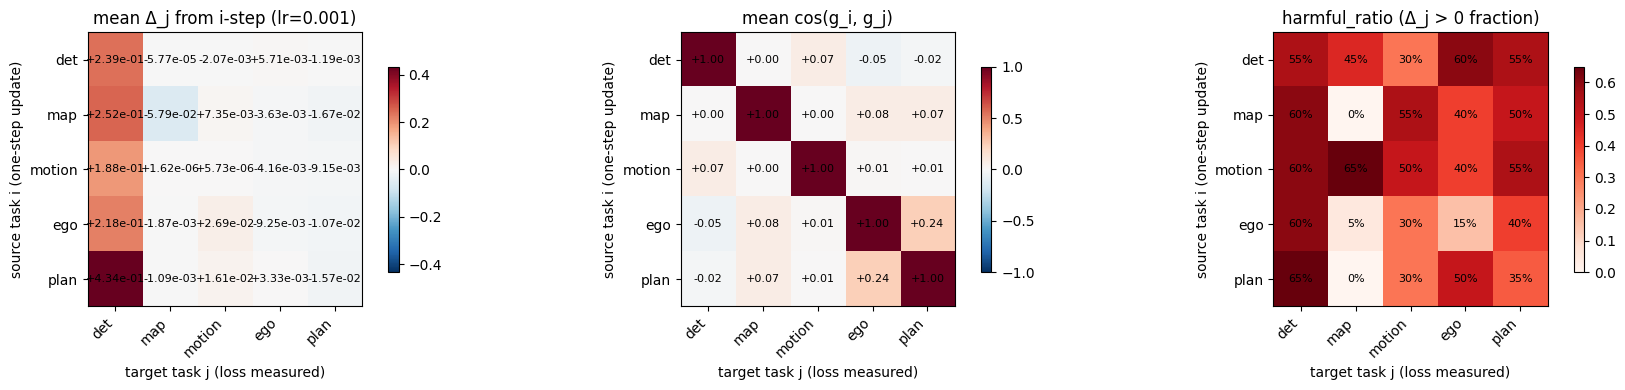

Saved heatmap: gradient_analysis_results/one_step_probe/one_step_probe_matrix.png


: 

: 

In [88]:
try:
    import matplotlib.pyplot as plt

    src_tasks = PROBE_TASKS
    tgt_tasks = TARGET_TASKS

    def build_mat(field):
        return np.array([
            [summary['matrix'][s][t].get(field, float('nan')) for t in tgt_tasks]
            for s in src_tasks
        ])

    M_delta   = build_mat('mean_delta')
    M_cos     = build_mat('mean_cos')
    M_harmful = build_mat('harmful_ratio')

    fig, axes = plt.subplots(1, 3, figsize=(18, 1 + 0.6 * len(src_tasks)))

    def heatmap(ax, mat, title, fmt, cmap, center_zero=False):
        if center_zero and np.isfinite(mat).any():
            absmax = np.nanmax(np.abs(mat))
            im = ax.imshow(mat, cmap=cmap, vmin=-absmax, vmax=absmax)
        else:
            im = ax.imshow(mat, cmap=cmap)
        ax.set_xticks(range(len(tgt_tasks))); ax.set_xticklabels(tgt_tasks, rotation=45, ha='right')
        ax.set_yticks(range(len(src_tasks))); ax.set_yticklabels(src_tasks)
        ax.set_xlabel('target task j (loss measured)')
        ax.set_ylabel('source task i (one-step update)')
        ax.set_title(title)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, fmt.format(v), ha='center', va='center',
                            fontsize=8, color='black')
        plt.colorbar(im, ax=ax, shrink=0.75)

    heatmap(axes[0], M_delta,   f'mean Δ_j from i-step (lr={VIRTUAL_LR})',
            '{:+.2e}', 'RdBu_r', center_zero=True)
    heatmap(axes[1], M_cos,     'mean cos(g_i, g_j)',
            '{:+.2f}', 'RdBu_r', center_zero=True)
    heatmap(axes[2], M_harmful, 'harmful_ratio (Δ_j > 0 fraction)',
            '{:.0%}', 'Reds')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'one_step_probe_matrix.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved heatmap: {plot_path}")
except Exception as e:
    print(f"Plotting skipped: {e}")
    traceback.print_exc()


## 8.5 Alignment hypothesis test

Q: *"task i와 j의 gradient가 aligned(cos>0)인 batch에서, i-step은 실제로 j-loss를 낮추는가?"*

각 (i, j) pair에 대해 per-batch로:
- `cos(g_i, g_j)` 와 `Δ_j_from_i` 의 pearson 상관 `ρ`
- `cos > 0` 인 batch 중 `Δ_j < 0` (cross-helpful) 인 비율
- `cos > 0` 인 batch 중 `Δ_j > 0` (cross-harmful despite alignment) 인 비율

해석:
- `ρ < 0` 이고 절댓값 큼 → cosine이 작을수록 Δ가 커짐 = **alignment가 cross-benefit 예측**
- `ρ > 0` → 오히려 cosine이 커질수록 Δ도 커짐 (harmful) = alignment가 misleading
- `ρ ≈ 0` → cosine과 실제 효과 무관


In [90]:
import numpy as np

src_tasks = PROBE_TASKS
tgt_tasks = TARGET_TASKS

def pull(src, tgt):
    cos_vals, dlt_vals = [], []
    for r in all_results:
        pr = r['per_probe'].get(src, {})
        if pr.get('failed'):
            continue
        c = pr.get('cos_vs', {}).get(tgt, float('nan'))
        d = pr.get('per_target', {}).get(tgt, {}).get('delta', float('nan'))
        if not (math.isnan(c) or math.isnan(d)):
            cos_vals.append(c); dlt_vals.append(d)
    return np.array(cos_vals), np.array(dlt_vals)


print("\n[Alignment Hypothesis]  4-quadrant breakdown per (src -> tgt)")
print("Linear theory predicts:  cos>0 -> Δ<0  AND  cos<0 -> Δ>0")
print("-" * 138)
hdr = (f"{'src':<8}{'tgt':<8}{'n':>4} {'ρ(cos,Δ)':>10} {'mean_cos':>10} {'mean_Δ':>12} "
       f"  {'cos>0&Δ<0':>11} {'cos>0&Δ>0':>11} || {'cos<0&Δ<0':>11} {'cos<0&Δ>0':>11}  {'verdict':>18}")
print(hdr)
print("-" * 138)

for src in src_tasks:
    for tgt in tgt_tasks:
        if src == tgt:
            continue
        c, d = pull(src, tgt)
        if len(c) < 2:
            print(f"{src:<8}{tgt:<8}{len(c):>4} (insufficient data)")
            continue
        rho = float(np.corrcoef(c, d)[0,1])
        pos = c > 0; neg = c < 0
        npos, nneg = int(pos.sum()), int(neg.sum())
        p_ph = (((d<0)&pos).sum()/npos) if npos else float('nan')  # cos>0 & Δ<0
        p_pp = (((d>0)&pos).sum()/npos) if npos else float('nan')  # cos>0 & Δ>0
        p_nh = (((d<0)&neg).sum()/nneg) if nneg else float('nan')  # cos<0 & Δ<0
        p_nn = (((d>0)&neg).sum()/nneg) if nneg else float('nan')  # cos<0 & Δ>0

        if abs(rho) < 0.2:
            verdict = "weak"
        elif rho < 0:
            verdict = "aligned→helpful"
        else:
            verdict = "aligned→harmful (!)"

        def fmt(v):
            return f"{v:>11.1%}" if not math.isnan(v) else f"{'N/A':>11s}"

        print(f"{src:<8}{tgt:<8}{len(c):>4} {rho:>+10.3f} {float(np.mean(c)):>+10.4f} "
              f"{float(np.mean(d)):>+12.3e}   "
              f"{fmt(p_ph)} {fmt(p_pp)} || {fmt(p_nh)} {fmt(p_nn)}  "
              f"{verdict:>18}")
print("-" * 138)
print("Legend:  cos>0&Δ<0 = aligned + helpful  (linear prediction hit on positive side)")
print("         cos<0&Δ>0 = anti-aligned + harmful  (linear prediction hit on negative side)")
print("         cos>0&Δ>0 & cos<0&Δ<0 are counter-examples to linear theory.\n")

print("\n[Self-vs-cross comparison] does j benefit MORE from i-step (i≠j) than from j-step?")
print(f"{'target j':<10} {'Δ_j from j (self)':>20} {'best cross src':>18} {'Δ_j from best src':>22}")
print("-" * 75)
for tgt in tgt_tasks:
    self_mean = summary['matrix'].get(tgt, {}).get(tgt, {}).get('mean_delta', float('nan')) \
                if tgt in PROBE_TASKS else float('nan')
    candidates = {s: summary['matrix'][s][tgt]['mean_delta']
                  for s in PROBE_TASKS if s != tgt}
    if not candidates:
        continue
    best_src = min(candidates, key=lambda s: (candidates[s] if not math.isnan(candidates[s]) else float('inf')))
    best_val = candidates[best_src]
    tag = "  <-- cross beats self" if (not math.isnan(self_mean)) and (best_val < self_mean) else ""
    print(f"{tgt:<10} {self_mean:>+20.3e} {best_src:>18s} {best_val:>+22.3e}{tag}")



[Alignment Hypothesis]  4-quadrant breakdown per (src -> tgt)
Linear theory predicts:  cos>0 -> Δ<0  AND  cos<0 -> Δ>0
------------------------------------------------------------------------------------------------------------------------------------------
src     tgt        n   ρ(cos,Δ)   mean_cos       mean_Δ     cos>0&Δ<0   cos>0&Δ>0 ||   cos<0&Δ<0   cos<0&Δ>0             verdict
------------------------------------------------------------------------------------------------------------------------------------------
det     map       20     -0.923    +0.0013   -5.774e-05         83.3%       16.7% ||       12.5%       87.5%     aligned→helpful
det     motion    20     +0.359    +0.0707   -2.070e-03         76.9%       23.1% ||       57.1%       42.9%  aligned→harmful (!)
det     ego       20     -0.159    -0.0538   +5.713e-03         66.7%       33.3% ||       35.3%       64.7%                weak
det     plan      20     +0.044    -0.0225   -1.191e-03         50.0%       50.0% || 

: 

: 

## 9. Usage summary

### Files created / modified
| File | Role |
|---|---|
| `tools/one_step_interference_probe.ipynb` | **New** — this notebook; end-to-end one-step probe pipeline. |
| `tools/analyze_gradient_conflict.py` | **Unchanged** — imported as helper module (`TASK_GROUPS`, `_sum_task_loss`, `_selective_eval`, `move_to_device`, `get_shared_parameters_grouped`, `compute_task_gradient_grouped`, `compute_cosine_similarity`). |

### Reused helpers
- `TASK_GROUPS` — loss-prefix taxonomy for det/map/motion/ego/plan (+ det_kd).
- `_sum_task_loss` — sums losses belonging to a task.
- `_selective_eval` — context manager: Dropout / BN / `DeformableFeatureAggregation` → eval, everything else → train.
- `move_to_device` — recursive tensor move.
- `get_shared_parameters_grouped` — shared decoder param groups (backbone/neck/norm/ffn/fc_*).
- `compute_task_gradient_grouped` — per-group gradient via a single `autograd.grad` call with `retain_graph` chaining.
- `compute_cosine_similarity` — for `cos_vs_focus`.

### New helpers in this notebook
- `extract_probe_params`, `flatten_param_group`, `group_boundaries_from` — parameter selection + layout.
- `backup_params`, `restore_params` — safe checkpoint / rollback without optimizer state.
- `apply_virtual_step` — in-place `p ← p − α·g` (raw or normalized, all-or-per-group scope).
- `_sum_task_loss_nograd` — variant that works on recompute outputs that may not carry grad.
- `clone_batch`, `forward_losses`, `forward_losses_nograd`, `extract_task_loss_values` — batch reuse and forward plumbing.
- `run_probe_on_batch` — the end-to-end per-batch before/virtual-step/after routine with guaranteed restore.
- `aggregate_probe_results` — mean / std / median / harmful-ratio aggregation.

### How to run
1. Open this notebook from the HiP-AD repo root (or from `tools/`).
2. Edit **§1 Configuration** — at minimum `CONFIG_PATH`, `CHECKPOINT_PATH`, `NUM_BATCHES`, `VIRTUAL_LR`.
3. Run cells top to bottom.

Equivalent CLI-style invocation (for reference / future port to a `.py` script):

```bash
python tools/analyze_gradient_conflict.py \
    --config projects/configs/hipad_nusc_stage2_pcgrad.py \
    --checkpoint work_dirs/hipad_nusc_stage2_pcgrad/latest.pth \
    --num-batches 20 --batch-size 6 --device cuda:0 --fp16 \
    --shared-layers backbone neck norm ffn fc_before fc_after \
    --focus-task plan --probe-tasks det map motion ego plan \
    --virtual-lr 1e-3 \
    --output-dir gradient_analysis_results/one_step_probe
#   (add --normalize-step and --no-selective-eval if desired)
```

### Output columns

**`one_step_probe_per_batch.csv`** — one row per mini-batch:

| Column | Meaning |
|---|---|
| `batch_idx` | Zero-based index of the mini-batch in the dataloader stream. |
| `baseline_{focus}_loss` | $L_{\text{focus}}(B, \theta)$ before any virtual step. |
| `baseline_{t}_loss` | Baseline summed task loss for each `t ∈ TASK_GROUPS` (det, det_kd, map, motion, ego, plan). |
| `delta_{focus}_from_{t}` | $L_{\text{focus}}(B, \theta - \alpha g_t) - L_{\text{focus}}(B, \theta)$. **Key metric.** |
| `rel_delta_{focus}_from_{t}` | Same, divided by $\lvert L_{\text{focus}}(B, \theta)\rvert + \epsilon$. |
| `focus_loss_after_{t}` | Raw $L_{\text{focus}}$ after probe-task `t`'s virtual step. |
| `grad_norm_{t}` | $\lVert g_t \rVert$ on shared params (before any normalization). |
| `cos_{t}_vs_{focus}` | Full-vector cosine between $g_t$ and $g_{\text{focus}}$ on shared params. |
| `failed_{t}` | `1` if that probe-task's step failed (null/zero gradient or runtime error). |

**`one_step_probe_summary.json`** — `{config, summary}` where `summary.per_probe[t]` contains:

| Field | Meaning |
|---|---|
| `n_valid`, `n_failed` | Counts of successful / failed probes across batches. |
| `mean_delta_focus`, `std_delta_focus`, `median_delta_focus` | Central tendency and dispersion of $\Delta L_{\text{focus}}$. |
| `mean_rel_delta_focus`, `std_rel_delta_focus` | Same, normalized by baseline magnitude. |
| `mean_cos_vs_focus` | Mean cosine with focus-task gradient. |
| `mean_grad_norm` | Mean $\lVert g_t \rVert$. |
| `harmful_ratio` | Fraction of mini-batches with $\Delta L_{\text{focus}} > 0$. |
| `helpful_ratio` | Fraction with $\Delta L_{\text{focus}} < 0$. |

### Design notes
- Baseline forward uses `autograd.grad` with `retain_graph=True` across all probe tasks so we pay for the expensive forward only once per mini-batch.
- The *recompute* forward after each virtual step is under `torch.no_grad()` (cheaper, leak-free).
- Parameter backup lives on the *same device as the param* but is `detach().clone()`ed, so no grad graph is retained. GPU memory overhead ≈ one extra copy of the shared param set.
- `optimizer.step()` is never called. AdamW moments are never touched.
- `restore_params` runs inside a `try/finally`, so even if an exception hits during the recompute, $\theta$ is rolled back before the next probe task.
- Same mini-batch is reused via `clone_batch()` to guarantee before/after determinism; dropout/BN state is frozen via `_selective_eval`.
